# XGBoost Improved

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBRegressor

### Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
train_df.head()

Train shape: (630000, 13)
Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### Preprocess

In [3]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                    'study_method', 'facility_rating', 'exam_difficulty']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

feature_cols = [c for c in train_df.columns if c not in ['id', 'exam_score']]

X = train_df[feature_cols]
y = train_df['exam_score']
X_submission = test_df[feature_cols]

print(f'Features: {feature_cols}')

Features: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


### Train/Validation Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Validation: {X_val.shape}')

Train: (504000, 11), Validation: (126000, 11)


### Train

In [5]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-rmse:18.21586
[100]	validation_0-rmse:8.83672
[200]	validation_0-rmse:8.78500
[300]	validation_0-rmse:8.77216
[400]	validation_0-rmse:8.76308
[500]	validation_0-rmse:8.75558
[600]	validation_0-rmse:8.75097
[700]	validation_0-rmse:8.74677
[800]	validation_0-rmse:8.74448
[900]	validation_0-rmse:8.74213
[999]	validation_0-rmse:8.74127

Best iteration: 998


In [6]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))

         feature  importance
     study_hours    0.533274
   sleep_quality    0.144994
 facility_rating    0.099571
    study_method    0.094434
class_attendance    0.089886
     sleep_hours    0.024149
             age    0.002917
          course    0.002853
          gender    0.002808
 exam_difficulty    0.002615
 internet_access    0.002497


### Evaluate

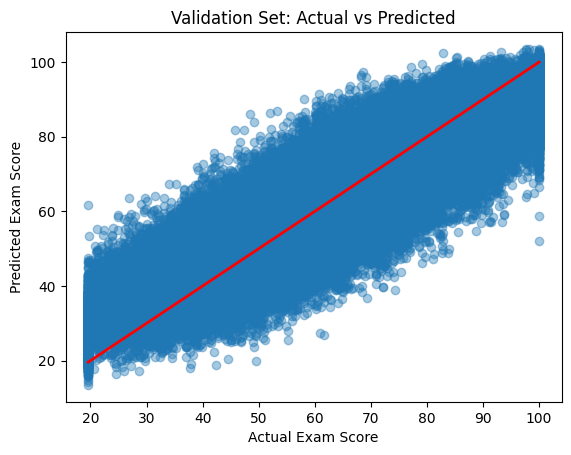

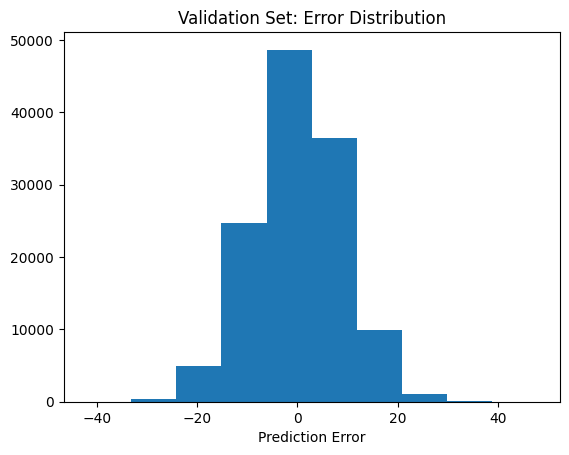

Metrics saved to ../metrics/xgboost_improved_metrics.csv


,MAE,MSE,RMSE,R2
0,6.967431,76.409712,8.741265,0.785153


In [7]:
y_val_pred = model.predict(X_val)

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Validation Set: Actual vs Predicted')
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel('Prediction Error')
plt.title('Validation Set: Error Distribution')
plt.show()

# Metrics
pd.set_option('float_format', '{:f}'.format)
res_metrics = pd.DataFrame({
    'MAE': [metrics.mean_absolute_error(y_val, y_val_pred)],
    'MSE': [metrics.mean_squared_error(y_val, y_val_pred)],
    'RMSE': [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    'R2': [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv('../metrics/xgboost_improved_metrics.csv', index=False)
print('Metrics saved to ../metrics/xgboost_improved_metrics.csv')
res_metrics

### Generate Submission

In [8]:
y_submission_pred = model.predict(X_submission)
submission = pd.DataFrame({'id': test_ids, 'exam_score': y_submission_pred})
submission.to_csv('../submission/xgboost_improved_submission.csv', index=False)
print('Submission saved to ../submission/xgboost_improved_submission.csv')
submission

Submission saved to ../submission/xgboost_improved_submission.csv


,id,exam_score
0,630000,71.465988
1,630001,69.727089
2,630002,88.295242
3,630003,56.689056
4,630004,48.338596
...,...,...
269995,899995,60.357479
269996,899996,39.452141
269997,899997,90.856819
269998,899998,54.504230


In [9]:
# Save model
joblib.dump(model, '../models/xgboost_improved.pkl')
print('Model saved to ../models/xgboost_improved.pkl')

Model saved to ../models/xgboost_improved.pkl
